In [2]:
from skimage import io, filters
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
filename = "drain_imbib-Stitched_final.tif"
# filename = "drain_imbib-Stitched_t0.tif"

currentDir = Path.cwd()
input_path = currentDir / filename
output_dir = currentDir / "threshold_results"
output_dir.mkdir(exist_ok=True)

In [4]:
# Load grayscale image
image = io.imread(input_path, as_gray=True)

# Apply local threshold
block_size = 35   # size of the neighborhood around each pixel
local_thresh = filters.threshold_local(image, block_size, offset=10)

# Binarize the image
binary_local = image > local_thresh

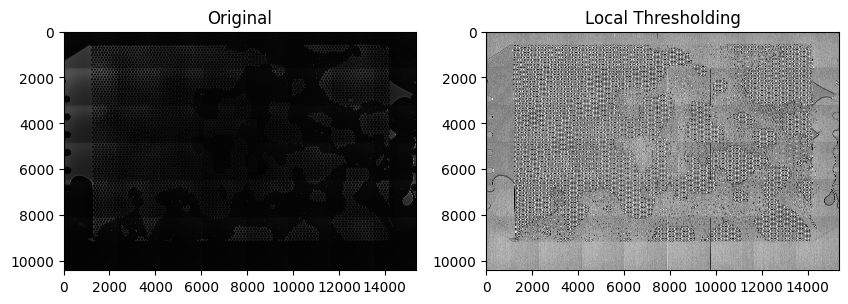

In [5]:
# Show results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original")
ax[1].imshow(binary_local, cmap='gray')
ax[1].set_title("Local Thresholding")
plt.show()

In [7]:
binary_check = binary_local.astype('uint8') * 255

In [ ]:
io.imsave(output_dir / f"{filename}_local_thresholding_v2.png",
          (binary_local.astype('uint8') * 255))